# Notebook 01: Análisis Exploratorio de Datos (EDA) Completo
Este notebook realiza el análisis exploratorio exhaustivo del dataset **IBM Telco Customer Churn** para identificar patrones de comportamiento, relaciones entre variables y posibles factores que influyen en la fuga de clientes (*Churn*).

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Ruta al dataset original
data_path = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(data_path)

print(f"Dimensiones originales: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dimensiones originales: 7043 filas, 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Detección y Limpieza de Tipos de Datos y Valores Faltantes
La variable `TotalCharges` se lee comúnmente como texto porque tiene espacios vacíos (`" "`) para registros de clientes nuevos (`tenure == 0`). Procedemos a realizar la conversión a numérica y a inspeccionar los nulos reales.

In [17]:
# Conversión de TotalCharges a numérico (coerción de errores a NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Revisión de tipos de datos
print("--- Tipos de Datos ---")
print(df.dtypes)

# Detección de nulos reales
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- Tipos de Datos ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

--- Conteo de Valores Nulos ---
TotalCharges    11
dtype: int64


In [18]:
# Ver registros nulos de TotalCharges
nulos_total_charges = df[df["TotalCharges"].isnull()]
print(f"Cantidad de nulos en TotalCharges: {len(nulos_total_charges)}")
nulos_total_charges[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head()

Cantidad de nulos en TotalCharges: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No


Como se observa, todos los valores nulos en `TotalCharges` corresponden a clientes con `tenure == 0` (nuevos clientes que aún no han completado su primer ciclo de facturación). Dado que son muy pocos registros (11 de 7043), procedemos a eliminarlos.

In [19]:
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop(columns=["customerID"], inplace=True, errors="ignore")
print(f"Dimensiones después de remover nulos: {df.shape[0]} filas")

Dimensiones después de remover nulos: 7032 filas


## 2. Análisis del Desbalance de la Variable Objetivo (Churn)

Distribución de Churn:
No: 5163 (73.42%)
Yes: 1869 (26.58%)


C:\Users\Mariana\AppData\Local\Temp\ipykernel_16300\3359066547.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", palette="coolwarm")


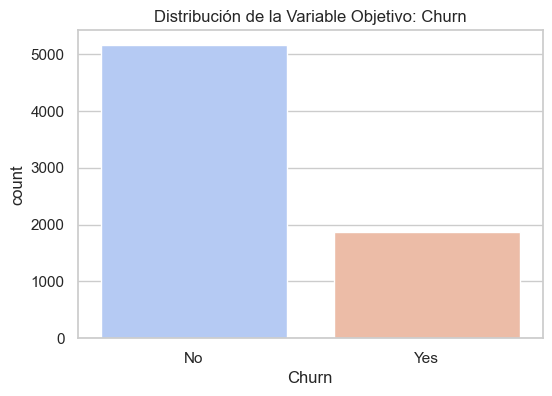

In [20]:
# Proporción de Churn
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Distribución de Churn:")
for index, count in churn_counts.items():
    print(f"{index}: {count} ({churn_pct[index]:.2f}%)")

# Gráfico de barras de Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn", palette="coolwarm")
plt.title("Distribución de la Variable Objetivo: Churn")
plt.show()

**Nota de negocio:** Existe un claro desbalanceo (~3:1). Solo un 26.58% de los clientes han abandonado la compañía. Esto requiere ajustar los modelos mediante técnicas de remuestreo o parámetros de peso (`scale_pos_weight` en XGBoost) para evitar que los clasificadores se sesguen a favor de la clase mayoritaria.

## 3. Análisis de Variables Numéricas y Correlaciones

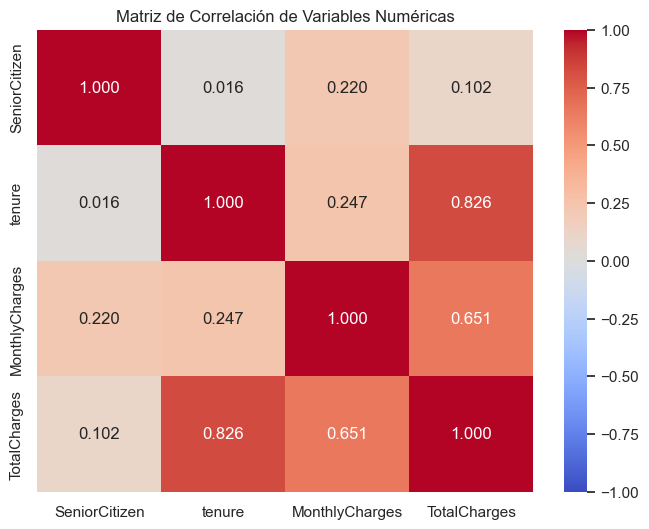

In [21]:
# Heatmap de correlación lineal completa (incluyendo TotalCharges)
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.select_dtypes(include="number").corr(), 
    annot=True, 
    cmap="coolwarm", 
    fmt=".3f", 
    vmin=-1, 
    vmax=1
)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

**Observaciones:** Hay una alta correlación lineal positiva (0.826) entre `TotalCharges` y `tenure`, lo cual es lógico ya que a mayor antigüedad el cliente acumula mayores cargos totales. También hay correlación positiva (0.651) entre `TotalCharges` y `MonthlyCharges`.

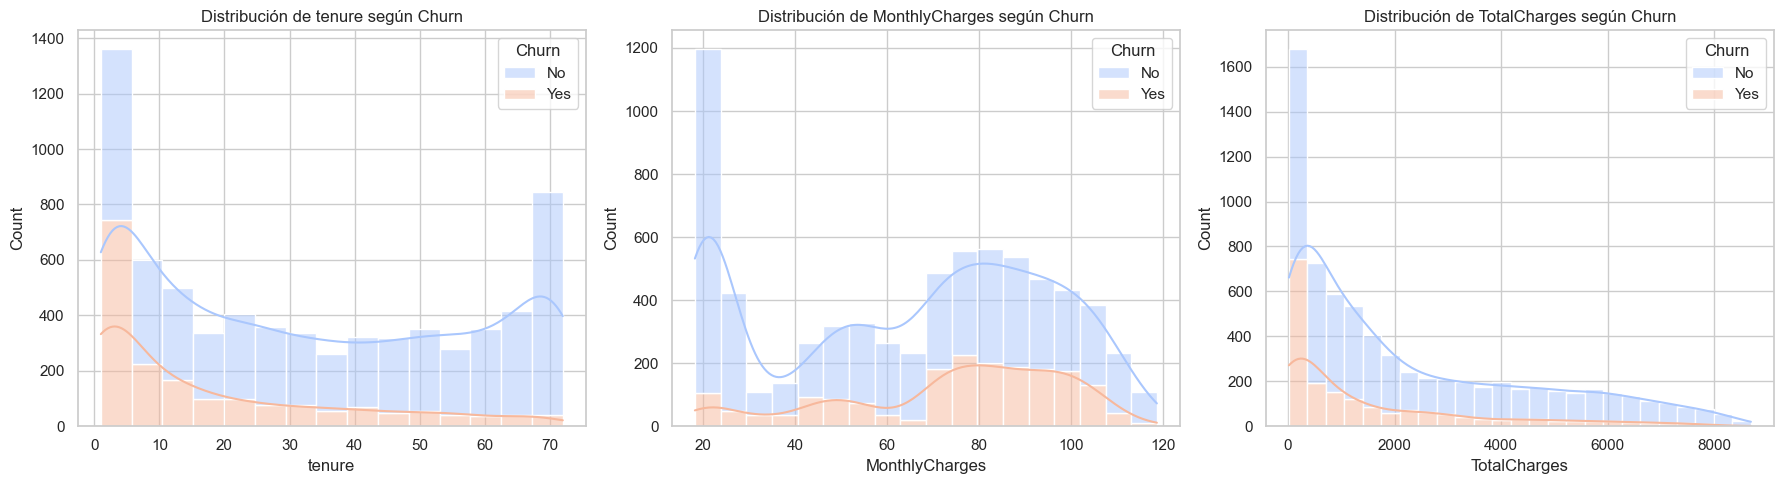

In [22]:
# Distribuciones de las variables numéricas clave
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, multiple="stack", ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"Distribución de {col} según Churn")

plt.tight_layout()
plt.show()

## 4. Análisis de Relación de Variables Categóricas clave con Churn

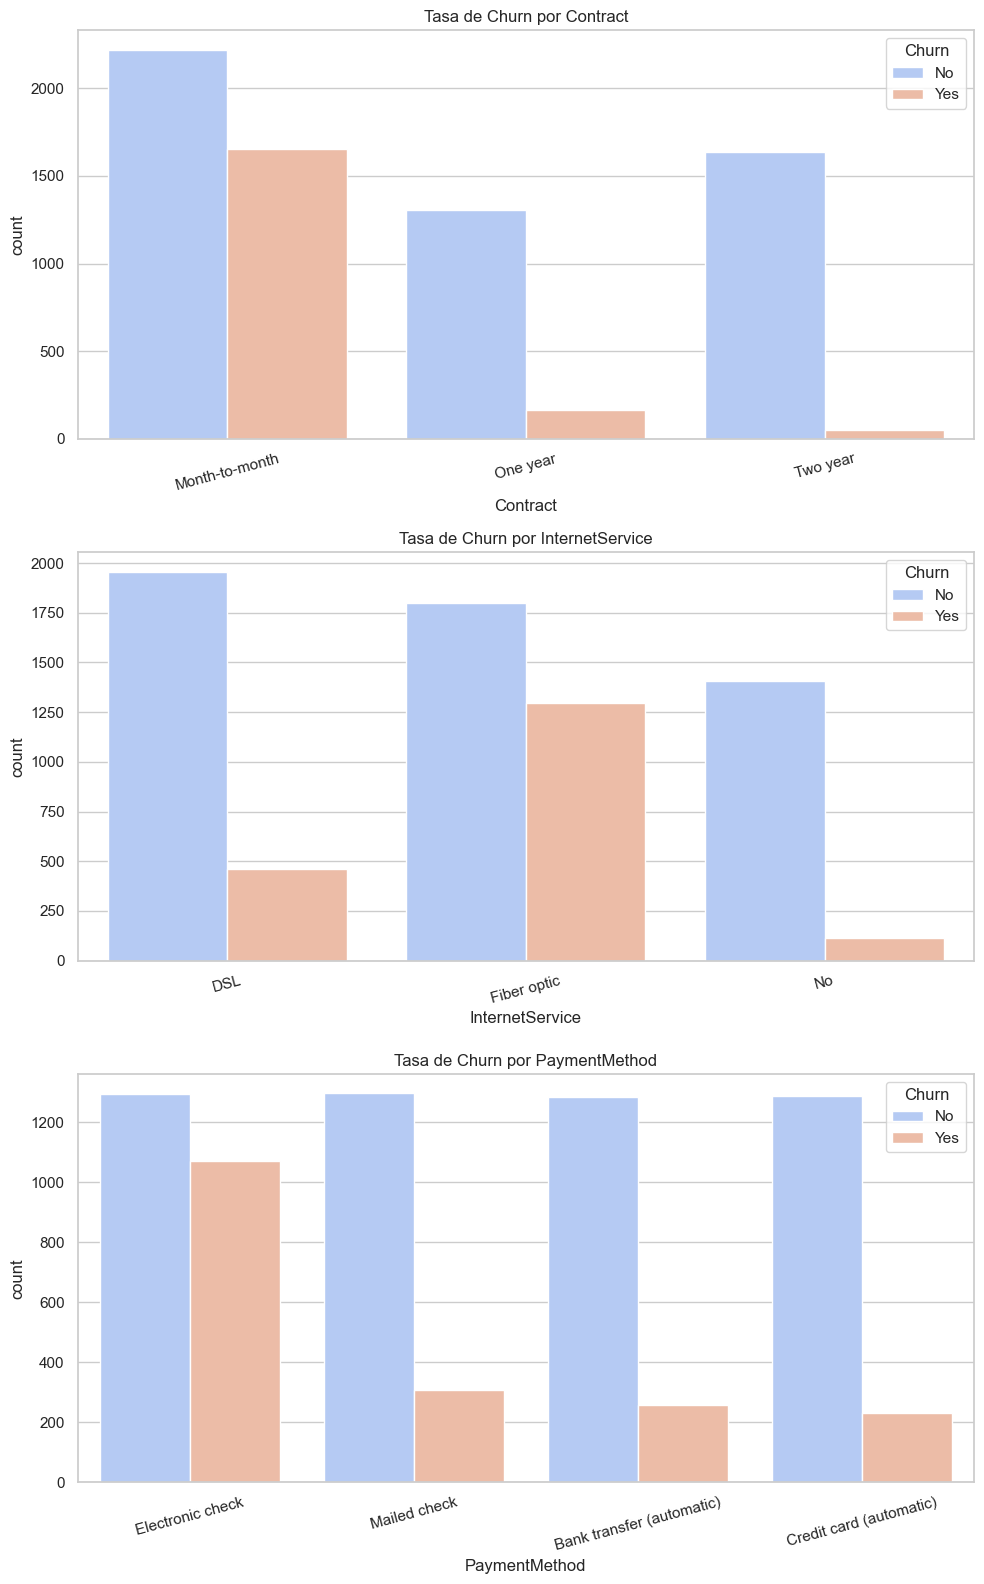

In [23]:
# Variables categóricas estratégicas
cat_cols = ["Contract", "InternetService", "PaymentMethod"]

fig, axes = plt.subplots(3, 1, figsize=(10, 16))
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=axes[i], palette="coolwarm")
    axes[i].set_title(f"Tasa de Churn por {col}")
    axes[i].tick_params(axis='x', rotation=15)
    
plt.tight_layout()
plt.show()

**Hallazgos Clave:**
1. **Tipo de Contrato:** Los clientes con contrato mes a mes (`Month-to-month`) muestran una tasa de deserción dramáticamente mayor en comparación con los contratos a 1 o 2 años.
2. **Servicio de Internet:** La deserción es notablemente más alta para los usuarios con internet de Fibra Óptica (`Fiber optic`), sugiriendo posibles descontentos con la tarifa o el servicio.
3. **Método de Pago:** Aquellos que pagan con cheque electrónico (`Electronic check`) tienen una deserción mucho mayor en comparación con métodos automáticos (tarjeta de crédito o transferencia bancaria).

### Justificación Teórica: Recall y F1-Score en Predicción de Churn

En este proyecto de predicción de fuga de clientes (*Churn*), priorizamos las métricas **Recall** (Sensibilidad) y **F1-Score** por encima del accuracy global o la precisión por las siguientes razones:

1. **Costo Asimétrico de los Errores (Priorización de Recall):**
   * **Falso Negativo (FN):** Clasificamos a un cliente que realmente se va a fugar como "leal". Como consecuencia, no tomamos ninguna acción y el cliente abandona la compañía. El costo de perder un cliente es extremadamente alto.
   * **Falso Positivo (FP):** Clasificamos a un cliente leal como "en riesgo de fuga" y le enviamos una oferta de retención. Esto tiene un costo menor (el margen de la oferta de retención), pero es preferible para conservar al cliente.
   * Por lo tanto, priorizamos un **Recall alto** para capturar al máximo número de clientes propensos a fugarse y minimizar los Falsos Negativos.

2. **Equilibrio Necesario ante Clases Desbalanceadas (Priorización de F1-Score):**
   * Si solo nos importara el Recall, el modelo podría predecir que todos los clientes van a fugarse (Recall del 100%), lo cual haría financieramente inviable cualquier campaña de retención.
   * El **F1-Score** es la media armónica entre Precision y Recall. Nos asegura que, mientras buscamos un Recall alto, el modelo mantenga una buena precisión para no inundar el departamento de marketing con Falsos Positivos innecesarios.

In [24]:
# Figura de distribución de la variable objetivo y mapa de correlaciones
import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = pathlib.Path(
    r"C:\Users\Mariana\Documents\vscodePROYECTOS\ChurnPredictor-LLM\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
df = pd.read_csv(DATA_PATH)

if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

plt.figure(figsize=(8, 10))               

# ------------------------------------------------------------------
# Distribución de la variable objetivo (Churn)
# ------------------------------------------------------------------
ax1 = plt.subplot(2, 1, 1)               
sns.countplot(
    data=df,
    x="Churn",
    order=["Yes", "No"],
    palette="rocket",
    ax=ax1
)
ax1.set_title("Distribución de la variable objetivo (Churn)", fontsize=12)
ax1.set_xlabel("")
ax1.set_ylabel("Frecuencia")

# ------------------------------------------------------------------
# Mapa de correlaciones (solo variables numéricas)
# ------------------------------------------------------------------
df_numeric = df.copy()
cat_cols = df_numeric.select_dtypes(include="object").columns
for col in cat_cols:
    df_numeric[col] = df_numeric[col].astype("category").cat.codes

corr = df_numeric.corr()

ax2 = plt.subplot(2, 1, 2)               
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"shrink": .6},
    square=True,
    ax=ax2
)
ax2.set_title("Mapa de correlaciones entre variables", fontsize=12)

# ------------------------------------------------------------------
# Guardar la imagen (dpi=200, tight layout)
# ------------------------------------------------------------------
OUT_PATH = pathlib.Path(
    r"C:\Users\Mariana\Documents\vscodePROYECTOS\ChurnPredictor-LLM\outputs\eda_target_corr.png"
)
plt.tight_layout()
plt.savefig(OUT_PATH, dpi=200, bbox_inches="tight")
plt.close()

print(f"Figura guardada en: {OUT_PATH}")


C:\Users\Mariana\AppData\Local\Temp\ipykernel_16300\347492081.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Mariana\AppData\Local\Temp\ipykernel_16300\347492081.py:36: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_numeric.select_dtypes(include="object").columns


Figura guardada en: C:\Users\Mariana\Documents\vscodePROYECTOS\ChurnPredictor-LLM\outputs\eda_target_corr.png
